#Carregar o arquivo train.csv

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo
df = pd.read_csv('train.csv')

# Quantidade de linhas e colunas
linhas, colunas = df.shape
print(f"Linhas: {linhas} | Colunas: {colunas}")

Linhas: 891 | Colunas: 12


#Tipos de dados Variaveis

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#Resumo Estatico

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#Analise da variavel "Survived"

/tmp/ipykernel_785/2143589763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


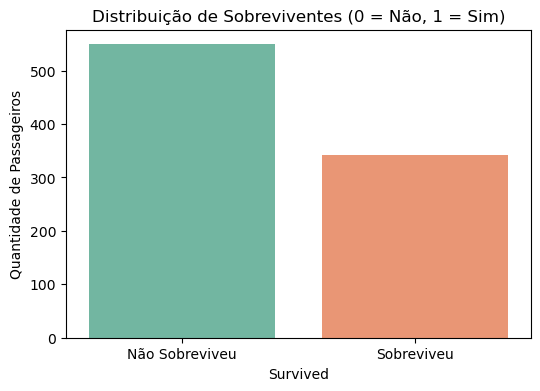

Pessoas que sobreviveram: 342
Classe mais frequente: 3ª classe


In [10]:
freq = df['Survived'].value_counts()
pct = df['Survived'].value_counts(normalize=True) * 100

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Distribuição de Sobreviventes (0 = Não, 1 = Sim)')
plt.xticks([0, 1], ['Não Sobreviveu', 'Sobreviveu'])
plt.ylabel('Quantidade de Passageiros')
plt.show()

print(f"Pessoas que sobreviveram: {freq[1]}")
print(f"Classe mais frequente: {df['Pclass'].mode()[0]}ª classe")

### Análise de Sobrevivência
* **Pessoas que sobreviveram:** 342 pessoas (38.4% do total).
* **Classe mais frequente:** A 3ª classe, com 491 passageiros.
* **Escolha do Gráfico:** O gráfico de barras (`countplot`) foi escolhido por se tratar de uma variável categórica nominal com poucas opções. Ele demonstra claramente a disparidade entre o grupo que sobreviveu e o que não sobreviveu.

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


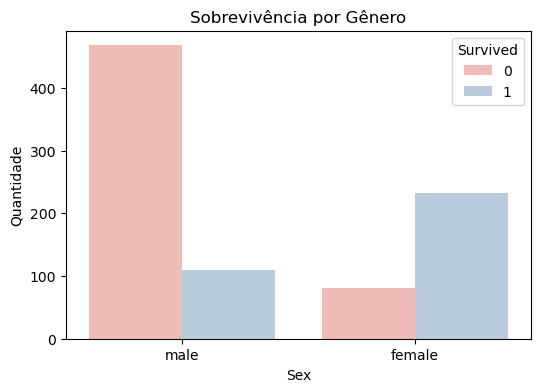

In [11]:
# Tabela cruzada em porcentagem por gênero
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)

# Gráfico de barras composto
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Pastel1')
plt.title('Sobrevivência por Gênero')
plt.ylabel('Quantidade')
plt.show()

### Relação entre Sexo e Sobrevivência
* **Mulheres sobreviveram mais que homens?** Sim. A análise mostra que **74.2% das mulheres** sobreviveram, enquanto apenas **18.9% dos homens** resistiram ao desastre. Isso valida a prioridade histórica de "mulheres e crianças primeiro" no acesso aos botes salva-vidas.

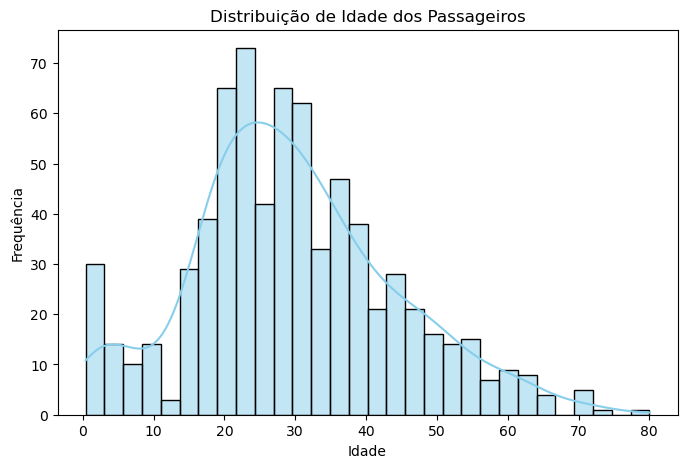

In [12]:
plt.figure(figsize=(8,5))
# O dropna() remove os valores vazios para não dar erro no gráfico
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue', bins=30)
plt.title('Distribuição de Idade dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

### Distribuição das Idades
* **Parece simétrica?** Não, ela não é perfeitamente simétrica. Ela possui uma assimetria à direita (cauda mais longa para idades avançadas) e um pequeno pico isolado no extremo esquerdo representando bebês e crianças pequenas.
* **Maioria jovem ou idosa?** A grande maioria dos passageiros era **jovem e jovem-adulta**, concentrando-se fortemente na faixa dos **18 aos 35 anos**. A quantidade de idosos acima de 60 anos era muito baixa.